## 1. Khởi tạo Môi trường & Khai báo Thư viện
Thiết lập môi trường làm việc và nạp các thư viện cốt lõi phục vụ cho luồng benchmarking và MLOps.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, roc_curve

sns.set_theme(style="whitegrid")

## 2. Tải dữ liệu & Tối ưu không gian đặc trưng 
Thực thi tải bộ dữ liệu đã qua tiền xử lý. Áp dụng cơ chế chọn lọc đặc trưng: loại bỏ các tín hiệu làm trơn (rolling mean/std), tập trung lưu giữ các biến mang tính chất phát hiện độ lệch (z-score, diff) nhằm tối ưu hóa bộ nhớ cho pha suy diễn.

In [2]:
# --- Tự động dò đường dẫn ---
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    PROJECT_ROOT = os.path.dirname(current_dir)
else:
    PROJECT_ROOT = current_dir

TRAIN_PATH = os.path.join(PROJECT_ROOT, "data", "features", "T1_train.csv")
TEST_PATH = os.path.join(PROJECT_ROOT, "data", "features", "T1_test.csv")

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

# --- Tối ưu Đặc trưng (Feature Selection) ---
features = [col for col in df_train.columns if ('zscore' in col) or ('diff' in col)]

X_train = df_train[features].values
X_test = df_test[features].values

print(f"[INFO] Số lượng features nạp vào luồng huấn luyện: {len(features)}")
print(f"[INFO] Danh sách không gian đặc trưng: {features}")

[INFO] Số lượng features nạp vào luồng huấn luyện: 6
[INFO] Danh sách không gian đặc trưng: ['LV ActivePower (kW)_zscore', 'Wind Speed (m/s)_zscore', 'Theoretical_Power_Curve (KWh)_zscore', 'LV ActivePower (kW)_diff_1', 'Wind Speed (m/s)_diff_1', 'Theoretical_Power_Curve (KWh)_diff_1']


## 3. Thiết lập nhãn giả cơ sở 
Dựa trên báo cáo thiết kế hệ thống, sử dụng phần dư công suất (Power Residual) làm hệ quy chiếu tĩnh. Các tín hiệu nằm ngoài khoảng $\pm3\sigma$ so với mức trung bình chuẩn hóa sẽ được gắn cờ dị thường (1), tạo ra bộ nhãn giả cơ sở phục vụ cho pha đánh giá hiệu năng.

In [3]:
# Tính giá trị trung bình và độ lệch chuẩn của phần dư công suất từ tập Train
mean_val = df_train['power_residual'].mean()
std_val = df_train['power_residual'].std()

# Xác định ngưỡng trên và ngưỡng dưới 
lower_bound = mean_val - 3 * std_val
upper_bound = mean_val + 3 * std_val

# Tạo nhãn giả cho tập Test (1: Bất thường, 0: Bình thường)
y_test_pseudo = ((df_test['power_residual'] < lower_bound) | 
                 (df_test['power_residual'] > upper_bound)).astype(int)

# Thống kê kết quả
anomalies_count = y_test_pseudo.sum()
print(f"[INFO] Tham số thống kê - Trung bình phần dư: {mean_val:.2f} | Độ lệch chuẩn: {std_val:.2f}")
print(f"[INFO] Thiết lập ngưỡng phân loại dị thường: < {lower_bound:.2f} hoặc > {upper_bound:.2f}")
print(f"[INFO] Tỷ lệ dữ liệu dị thường rớt vào tập Test: {anomalies_count} records ({anomalies_count/len(y_test_pseudo)*100:.2f}%)")

[INFO] Tham số thống kê - Trung bình phần dư: -0.00 | Độ lệch chuẩn: 1.00
[INFO] Thiết lập ngưỡng phân loại dị thường: < -3.00 hoặc > 3.00
[INFO] Tỷ lệ dữ liệu dị thường rớt vào tập Test: 207 records (1.31%)


## 4. Chuẩn đối sánh Hiệu năng (Model Benchmarking Pipeline) 
Thực thi huấn luyện đồng thời các kiến trúc thuật toán trong khối Học máy truyền thống. 

In [4]:
# Cấu hình tỷ lệ bất thường tiên nghiệm (Prior contamination)
CONTAMINATION = 0.015

print("[INFO] Khởi chạy luồng chuẩn đối sánh (benchmarking Pipeline)...")

# 1. Khởi tạo kiến trúc Challenger 1: Isolation Forest
print("[INFO] 1/3 - Đang huấn luyện Isolation Forest...")
iforest = IsolationForest(n_estimators=150, contamination=CONTAMINATION, random_state=42, n_jobs=-1)
iforest.fit(X_train)
scores_iforest = -iforest.score_samples(X_test)
preds_iforest = np.where(iforest.predict(X_test) == -1, 1, 0)

# 2. Khởi tạo kiến trúc Champion (Tạm thời): Gaussian Mixture Model (GMM)
print("[INFO] 2/3 - Đang huấn luyện Gaussian Mixture Model...")
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
gmm.fit(X_train)
scores_gmm = -gmm.score_samples(X_test)
threshold_gmm = np.percentile(scores_gmm, 100 * (1 - CONTAMINATION))
preds_gmm = (scores_gmm > threshold_gmm).astype(int)

# 3. Khởi tạo kiến trúc Challenger 2: Hybrid (PCA + Isolation Forest)
print("[INFO] 3/3 - Đang huấn luyện Hybrid Architecture (PCA + Isolation Forest)...")
hybrid_model = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('iforest', IsolationForest(n_estimators=150, contamination=CONTAMINATION, random_state=42, n_jobs=-1))
])
hybrid_model.fit(X_train)
X_test_pca = hybrid_model.named_steps['pca'].transform(X_test)
scores_hybrid = -hybrid_model.named_steps['iforest'].score_samples(X_test_pca)
preds_hybrid = np.where(hybrid_model.predict(X_test) == -1, 1, 0)

print("\n[INFO] Hoàn tất luồng huấn luyện các mô hình cơ sở.")

[INFO] Khởi chạy luồng chuẩn đối sánh (benchmarking Pipeline)...
[INFO] 1/3 - Đang huấn luyện Isolation Forest...
[INFO] 2/3 - Đang huấn luyện Gaussian Mixture Model...
[INFO] 3/3 - Đang huấn luyện Hybrid Architecture (PCA + Isolation Forest)...

[INFO] Hoàn tất luồng huấn luyện các mô hình cơ sở.



[RESULT] Bảng Tổng hợp Chỉ số Đánh giá:
Model Architecture  ROC-AUC  F1-Score
    GMM (Champion) 0.931211  0.157658
  Isolation Forest 0.881257  0.037037
     Hybrid PCA+IF 0.761193  0.107527


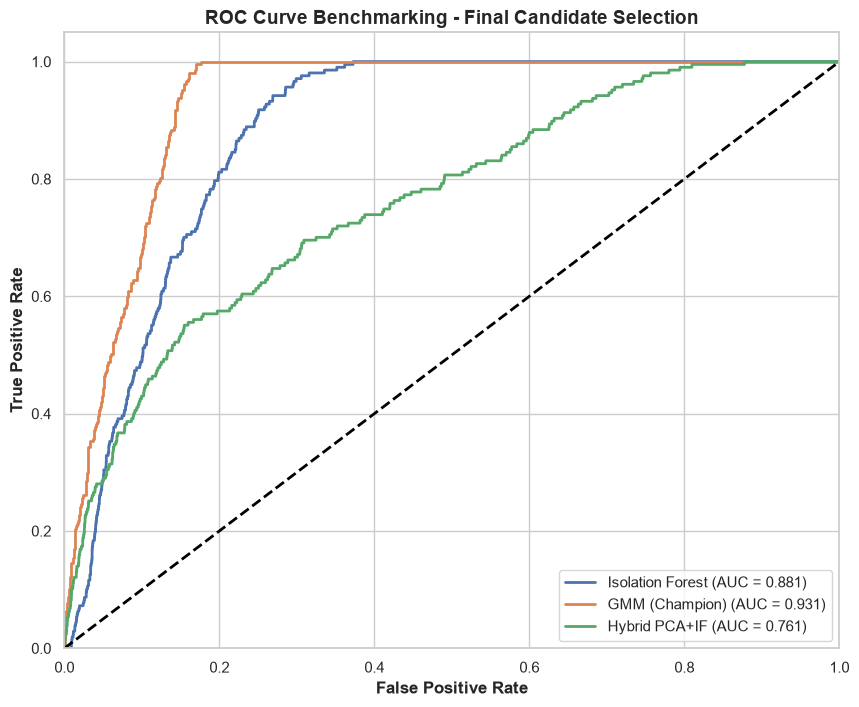

In [ ]:
print("\n[RESULT] Bảng Tổng hợp Chỉ số Đánh giá:")
models = {
    "Isolation Forest": (preds_iforest, scores_iforest),
    "GMM": (preds_gmm, scores_gmm),
    "Hybrid PCA+IF": (preds_hybrid, scores_hybrid)
}

results = []
for name, (preds, scores) in models.items():
    auc = roc_auc_score(y_test_pseudo, scores)
    f1 = f1_score(y_test_pseudo, preds)
    results.append({"Model Architecture": name, "ROC-AUC": auc, "F1-Score": f1})

df_results = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
try:
    print(df_results.to_markdown(index=False))
except Exception:
    print(df_results.to_string(index=False))

# Trực quan hóa ROC Curve
plt.figure(figsize=(10, 8))
for name, (_, scores) in models.items():
    fpr, tpr, _ = roc_curve(y_test_pseudo, scores)
    auc_score = roc_auc_score(y_test_pseudo, scores)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curve Benchmarking - Final Candidate Selection', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()